### Imports and configuration

In [14]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import shap

sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
TEST_SIZE = 0.20

SHAP_SAMPLE_SIZE = 350
BACKGROUND_SAMPLE_SIZE = 1000
TOP_N_FEATURES = 25

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

print("Project root:", PROJECT_ROOT)
print("Processed data directory:", DATA_DIR)
print("Models directory:", MODELS_DIR)

Project root: /home/patryk/Programming/MIO/social-media-engagement-prediction
Processed data directory: /home/patryk/Programming/MIO/social-media-engagement-prediction/data/processed
Models directory: /home/patryk/Programming/MIO/social-media-engagement-prediction/models


### Load model, matrices, metadata and processed DataFrame

In [15]:
model_path = MODELS_DIR / "best_engagement_model.joblib"
if not model_path.exists():
    raise FileNotFoundError(
        f"Missing {model_path}. Run notebook 04_models.ipynb first so the best model is trained and saved."
    )

bundle = joblib.load(model_path)

best_model_name = bundle["model_name"]
best_model = bundle["model"]
best_feature_names = list(bundle["feature_names"])
label_classes = np.array(bundle["label_classes"])
train_idx = np.array(bundle["train_idx"])
test_idx = np.array(bundle["test_idx"])

print("Best model:", best_model_name)
print("Model type:", type(best_model).__name__)
print("Number of classes:", len(label_classes))
print("Classes:", dict(enumerate(label_classes)))
print("Feature names in bundle:", len(best_feature_names))
print("Train/test sizes:", len(train_idx), len(test_idx))

Best model: Logistic Regression - TF-IDF + numeric
Model type: LogisticRegression
Number of classes: 3
Classes: {0: 'High', 1: 'Low', 2: 'Medium'}
Feature names in bundle: 10045
Train/test sizes: 34681 8671


In [16]:
X_tfidf = sp.load_npz(DATA_DIR / "X_tfidf_features.npz")
X_count = sp.load_npz(DATA_DIR / "X_count_features.npz")
y = np.load(DATA_DIR / "y_labels.npy")

with open(DATA_DIR / "feature_names_tfidf.json", "r") as f:
    feature_names_tfidf = json.load(f)

with open(DATA_DIR / "feature_names_count.json", "r") as f:
    feature_names_count = json.load(f)

df_path = DATA_DIR / "df_with_features.csv"
df = pd.read_csv(df_path) if df_path.exists() else None

print("X_tfidf:", X_tfidf.shape)
print("X_count:", X_count.shape)
print("y:", y.shape)
print("TF-IDF names:", len(feature_names_tfidf))
print("Count names:", len(feature_names_count))
print("df loaded:", df is not None)

assert len(y) == X_tfidf.shape[0] == X_count.shape[0]
assert X_tfidf.shape[1] == len(feature_names_tfidf)
assert X_count.shape[1] == len(feature_names_count)
if df is not None:
    assert len(df) == len(y)

X_tfidf: (43352, 10045)
X_count: (43352, 10045)
y: (43352,)
TF-IDF names: 10045
Count names: 10045
df loaded: True


### Select the correct feature matrix for the saved model

In [17]:
NUMERICAL_FEATURES = [
    "exclamation_count",
    "question_count",
    "capslock_words_count",
    "word_count",
    "sentence_count",
    "char_count",
    "hashtag_count",
    "mention_count",
    "has_url",
    "has_media_link",
    "url_count",
    "exclamation_per_word",
    "question_per_word",
    "ends_with_exclamation",
    "ends_with_question",
    "max_exclamation_run",
    "first_person_singular_count",
    "first_person_plural_count",
    "second_person_count",
    "modal_count",
    "negation_count",
    "emphatic_word_count",
    "certainty_word_count",
    "superlative_word_count",
    "negative_emphatic_word_count",
    "avg_word_length",
    "avg_sentence_length",
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "repetition_ratio",
    "shouting_index",
    "lexical_diversity_ttr",
    "sent_vader_compound",
    "sent_vader_neg",
    "sent_vader_neu",
    "sent_vader_pos",
    "has_number",
    "number_token_count",
    "has_year_mention",
    "has_large_number",
    "topic_lda_1",
    "topic_lda_2",
    "topic_lda_3",
    "topic_lda_4",
    "topic_lda_5",
]

n_numeric = len(NUMERICAL_FEATURES)

# Detect representation robustly.
if len(best_feature_names) == X_tfidf.shape[1]:
    X_all = X_tfidf
    selected_representation = "tfidf+numeric"
elif len(best_feature_names) == X_count.shape[1]:
    X_all = X_count
    selected_representation = "count+numeric"
elif "count text only" in best_model_name.lower():
    # The full count matrix contains text + numeric. Text-only is the left block.
    n_count_text_features = X_count.shape[1] - n_numeric
    X_all = X_count[:, :n_count_text_features]
    selected_representation = "count text only"
    best_feature_names = feature_names_count[:n_count_text_features]
else:
    raise ValueError(
        "Could not determine which feature matrix matches the saved model. "
        f"Model has {len(best_feature_names)} features, X_tfidf has {X_tfidf.shape[1]}, X_count has {X_count.shape[1]}."
    )

X_train = X_all[train_idx]
X_test = X_all[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print("Selected representation:", selected_representation)
print("X_all:", X_all.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Feature names:", len(best_feature_names))
assert X_all.shape[1] == len(best_feature_names)

Selected representation: tfidf+numeric
X_all: (43352, 10045)
X_train: (34681, 10045)
X_test: (8671, 10045)
Feature names: 10045


### Confirm model performance on the test set

,precision,recall,f1-score,support
High,0.899326,0.877855,0.888461,2890.000000
Low,0.815075,0.837810,0.826286,2904.000000
Medium,0.740314,0.737226,0.738767,2877.000000
accuracy,0.817783,0.817783,0.817783,0.817783
macro avg,0.818239,0.817630,0.817838,8671.000000
weighted avg,0.818350,0.817783,0.817970,8671.000000


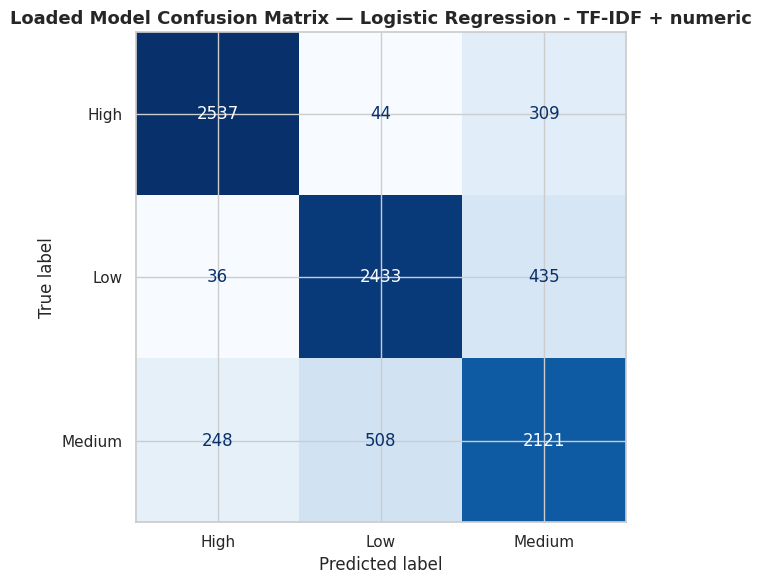

In [18]:
y_pred = best_model.predict(X_test)

report = classification_report(
    y_test,
    y_pred,
    target_names=label_classes,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T
display(report_df)

cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(label_classes)))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=label_classes).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
plt.title(f"Loaded Model Confusion Matrix — {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Prepare a manageable SHAP sample

In [19]:
rng = np.random.default_rng(RANDOM_STATE)

sample_size = min(SHAP_SAMPLE_SIZE, X_test.shape[0])
sample_positions = rng.choice(np.arange(X_test.shape[0]), size=sample_size, replace=False)
sample_positions = np.sort(sample_positions)

background_size = min(BACKGROUND_SAMPLE_SIZE, X_train.shape[0])
background_positions = rng.choice(np.arange(X_train.shape[0]), size=background_size, replace=False)

X_explain = X_test[sample_positions]
y_explain = y_test[sample_positions]
pred_explain = y_pred[sample_positions]
row_indices_explain = test_idx[sample_positions]
X_background = X_train[background_positions]

print("X_background:", X_background.shape)
print("X_explain:", X_explain.shape)
print("Explained class distribution:")
display(pd.Series([label_classes[i] for i in y_explain]).value_counts().rename_axis("class").to_frame("count"))

X_background: (1000, 10045)
X_explain: (350, 10045)
Explained class distribution:


,count
class,
Low,119
Medium,117
High,114


### Compute SHAP values

Interpretation for multiclass classifiers:

- A **positive SHAP value** for class `k` pushes the model score toward class `k`.
- A **negative SHAP value** pushes the model score away from class `k`.
- Values are in the model score space, not direct probabilities.

In [20]:
def _as_dense(matrix):
    return matrix.toarray() if sp.issparse(matrix) else np.asarray(matrix)


def normalize_shap_output(shap_output, X_sample, X_bg, model):
    """
    Convert shap output to a common shape: n_samples x n_features x n_classes.
    """
    X_dense = _as_dense(X_sample)

    # Newer SHAP: Explanation object.
    if hasattr(shap_output, "values"):
        vals = np.asarray(shap_output.values)
        base = np.asarray(shap_output.base_values)
    # Older SHAP: list of arrays, one per class.
    elif isinstance(shap_output, list):
        vals = np.stack([np.asarray(v) for v in shap_output], axis=-1)
        base = np.zeros((X_dense.shape[0], vals.shape[-1]))
    else:
        vals = np.asarray(shap_output)
        base = np.zeros((X_dense.shape[0], 1))

    if vals.ndim == 2:
        vals = vals[:, :, None]
    elif vals.ndim == 3:
        # Expected already: n_samples x n_features x n_classes.
        pass
    else:
        raise ValueError(f"Unexpected SHAP value shape: {vals.shape}")

    if base.ndim == 1:
        if base.shape[0] == vals.shape[-1]:
            base = np.tile(base, (vals.shape[0], 1))
        elif base.shape[0] == vals.shape[0]:
            base = base[:, None]

    return vals.astype(np.float32), base, X_dense


if "xgb" in best_model_name.lower() or "forest" in best_model_name.lower():
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model, X_background)
shap_raw = explainer(X_explain)
shap_values, base_values, X_explain_dense = normalize_shap_output(shap_raw, X_explain, X_background, best_model)
shap_method = "shap.LinearExplainer"


print("SHAP method:", shap_method)
print("shap_values shape:", shap_values.shape)
print("base_values shape:", np.asarray(base_values).shape)
print("X_explain_dense shape:", X_explain_dense.shape)

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


SHAP method: shap.LinearExplainer
shap_values shape: (350, 10045, 3)
base_values shape: (350, 3)
X_explain_dense shape: (350, 10045)


### Global SHAP importance across all classes

,feature,mean_abs_shap,feature_type
0,word_count,0.531047,engineered_numeric
1,mention_count,0.494080,engineered_numeric
2,flesch_reading_ease,0.456526,engineered_numeric
3,avg_sentence_length,0.320327,engineered_numeric
4,flesch_kincaid_grade,0.293125,engineered_numeric
5,char_count,0.275070,engineered_numeric
6,topic_lda_3,0.261158,engineered_numeric
7,has_media_link,0.245664,engineered_numeric
8,exclamation_count,0.234946,engineered_numeric
9,max_exclamation_run,0.204501,engineered_numeric


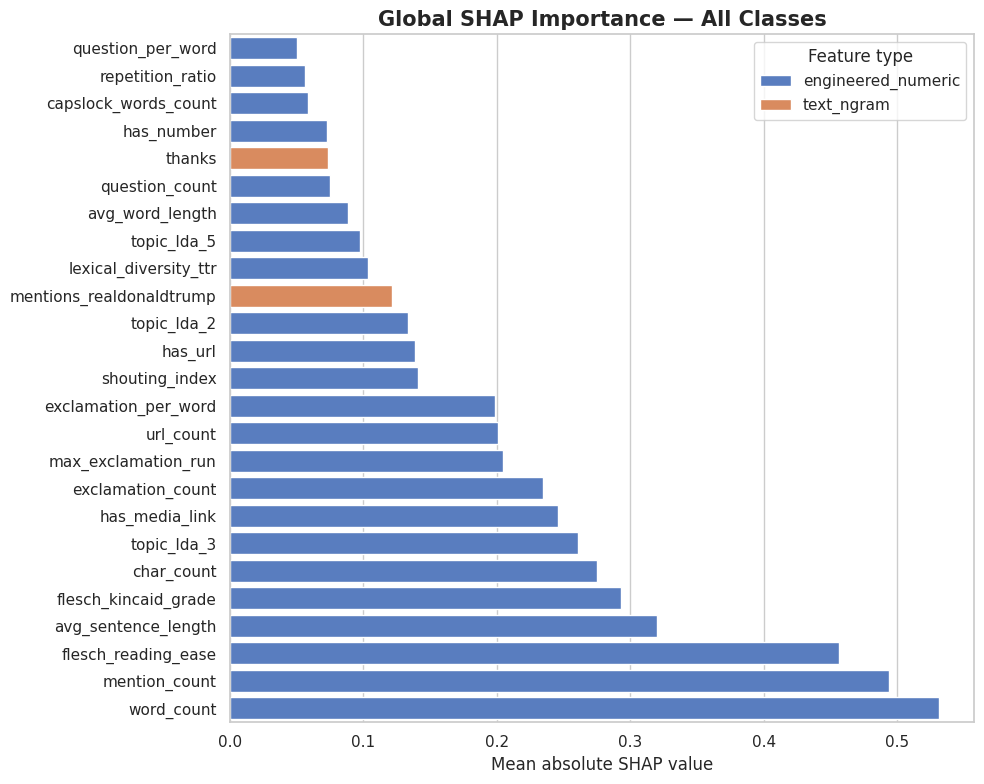

In [21]:
mean_abs_all = np.abs(shap_values).mean(axis=(0, 2))

global_importance = pd.DataFrame({
    "feature": best_feature_names,
    "mean_abs_shap": mean_abs_all,
})

global_importance["feature_type"] = np.where(
    global_importance["feature"].isin(NUMERICAL_FEATURES),
    "engineered_numeric",
    "text_ngram",
)

global_importance = global_importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

display(global_importance.head(30))

plt.figure(figsize=(10, 8))
plot_df = global_importance.head(TOP_N_FEATURES).iloc[::-1]
sns.barplot(data=plot_df, x="mean_abs_shap", y="feature", hue="feature_type", dodge=False)
plt.title("Global SHAP Importance — All Classes", fontsize=15, fontweight="bold")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("")
plt.legend(title="Feature type")
plt.tight_layout()
plt.show()

### SHAP importance by engagement class

,class_id,class_name,feature,mean_abs_shap,mean_signed_shap,feature_type
0,0,High,mention_count,0.741119,0.005895,engineered_numeric
1,0,High,flesch_reading_ease,0.684789,-0.223125,engineered_numeric
2,0,High,word_count,0.660667,0.106886,engineered_numeric
3,0,High,flesch_kincaid_grade,0.439687,0.137130,engineered_numeric
4,0,High,char_count,0.412605,-0.001330,engineered_numeric
5,0,High,topic_lda_3,0.391737,-0.012658,engineered_numeric
6,0,High,exclamation_count,0.352419,-0.006518,engineered_numeric
7,0,High,has_media_link,0.315886,-0.027045,engineered_numeric
8,0,High,max_exclamation_run,0.306752,-0.016348,engineered_numeric
9,0,High,url_count,0.301874,0.099140,engineered_numeric


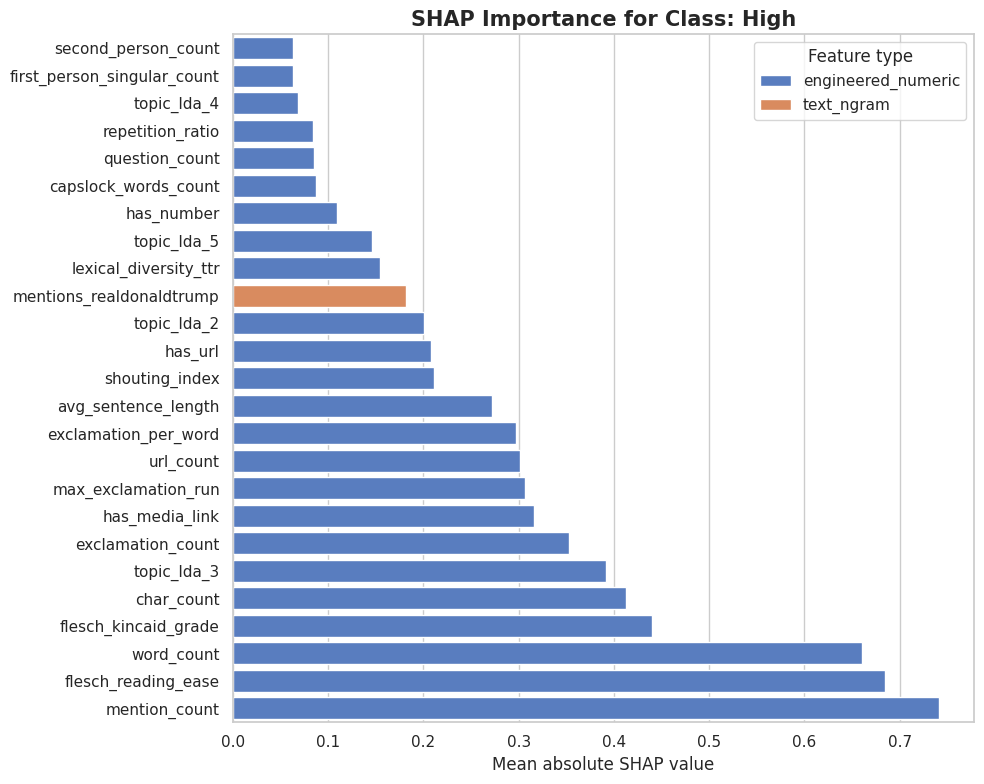

,class_id,class_name,feature,mean_abs_shap,mean_signed_shap,feature_type
0,1,Low,word_count,0.796571,-0.128873,engineered_numeric
1,1,Low,mention_count,0.719034,-0.005719,engineered_numeric
2,1,Low,flesch_reading_ease,0.670319,0.218410,engineered_numeric
3,1,Low,avg_sentence_length,0.480491,0.075358,engineered_numeric
4,1,Low,flesch_kincaid_grade,0.376521,-0.117430,engineered_numeric
5,1,Low,has_media_link,0.368496,0.031549,engineered_numeric
6,1,Low,topic_lda_3,0.323117,0.010441,engineered_numeric
7,1,Low,char_count,0.267745,0.000863,engineered_numeric
8,1,Low,max_exclamation_run,0.220039,0.011727,engineered_numeric
9,1,Low,url_count,0.217067,-0.071289,engineered_numeric


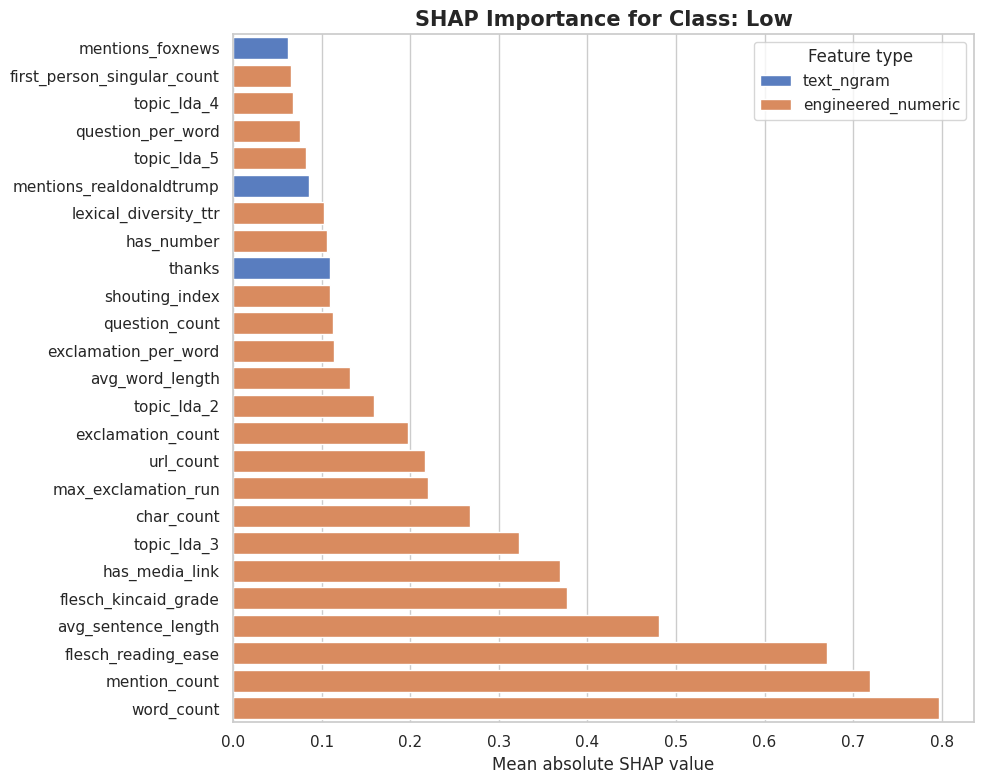

,class_id,class_name,feature,mean_abs_shap,mean_signed_shap,feature_type
0,2,Medium,avg_sentence_length,0.208961,-0.032772,engineered_numeric
1,2,Medium,has_url,0.197949,0.065313,engineered_numeric
2,2,Medium,exclamation_per_word,0.183449,0.038002,engineered_numeric
3,2,Medium,exclamation_count,0.155075,0.002868,engineered_numeric
4,2,Medium,char_count,0.144860,0.000467,engineered_numeric
5,2,Medium,word_count,0.135904,0.021987,engineered_numeric
6,2,Medium,shouting_index,0.101608,0.027517,engineered_numeric
7,2,Medium,mentions_realdonaldtrump,0.095524,0.001526,text_ngram
8,2,Medium,max_exclamation_run,0.086713,0.004621,engineered_numeric
9,2,Medium,url_count,0.084806,-0.027852,engineered_numeric


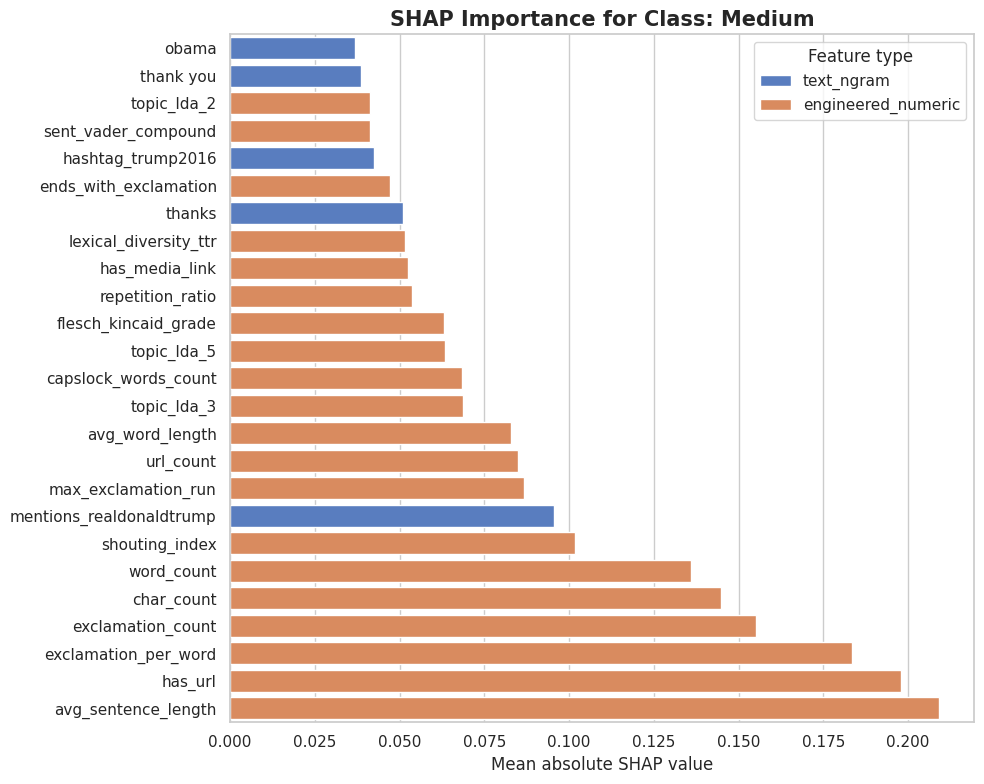

In [22]:
class_importance_tables = []

for class_idx, class_name in enumerate(label_classes):
    if class_idx >= shap_values.shape[-1]:
        continue

    mean_abs = np.abs(shap_values[:, :, class_idx]).mean(axis=0)
    mean_signed = shap_values[:, :, class_idx].mean(axis=0)

    class_df = pd.DataFrame({
        "class_id": class_idx,
        "class_name": class_name,
        "feature": best_feature_names,
        "mean_abs_shap": mean_abs,
        "mean_signed_shap": mean_signed,
    })
    class_df["feature_type"] = np.where(
        class_df["feature"].isin(NUMERICAL_FEATURES),
        "engineered_numeric",
        "text_ngram",
    )
    class_df = class_df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    class_importance_tables.append(class_df)

    display(class_df.head(20))

    plt.figure(figsize=(10, 8))
    plot_df = class_df.head(TOP_N_FEATURES).iloc[::-1]
    sns.barplot(data=plot_df, x="mean_abs_shap", y="feature", hue="feature_type", dodge=False)
    plt.title(f"SHAP Importance for Class: {class_name}", fontsize=15, fontweight="bold")
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("")
    plt.legend(title="Feature type")
    plt.tight_layout()
    safe_name = str(class_name).replace(" ", "_").lower()
    plt.show()

class_importance_all = pd.concat(class_importance_tables, ignore_index=True)

### Direction of influence: positive vs negative SHAP values

Interpretation:

- Positive mean SHAP: feature tends to push predictions toward that class.
- Negative mean SHAP: feature tends to push predictions away from that class.

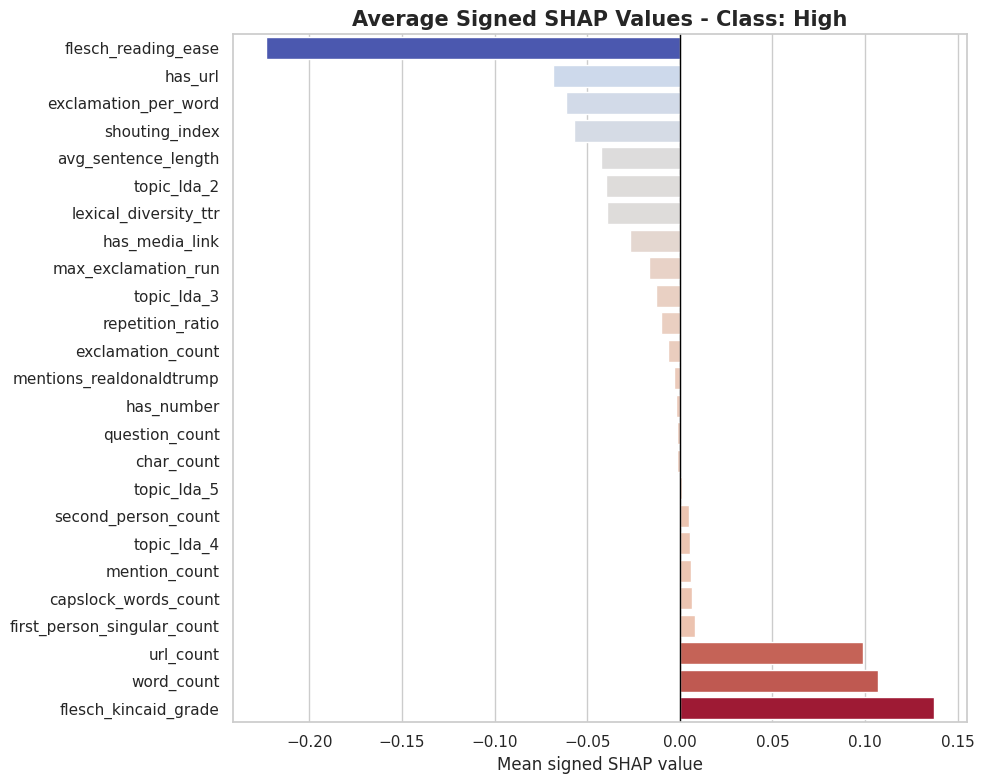

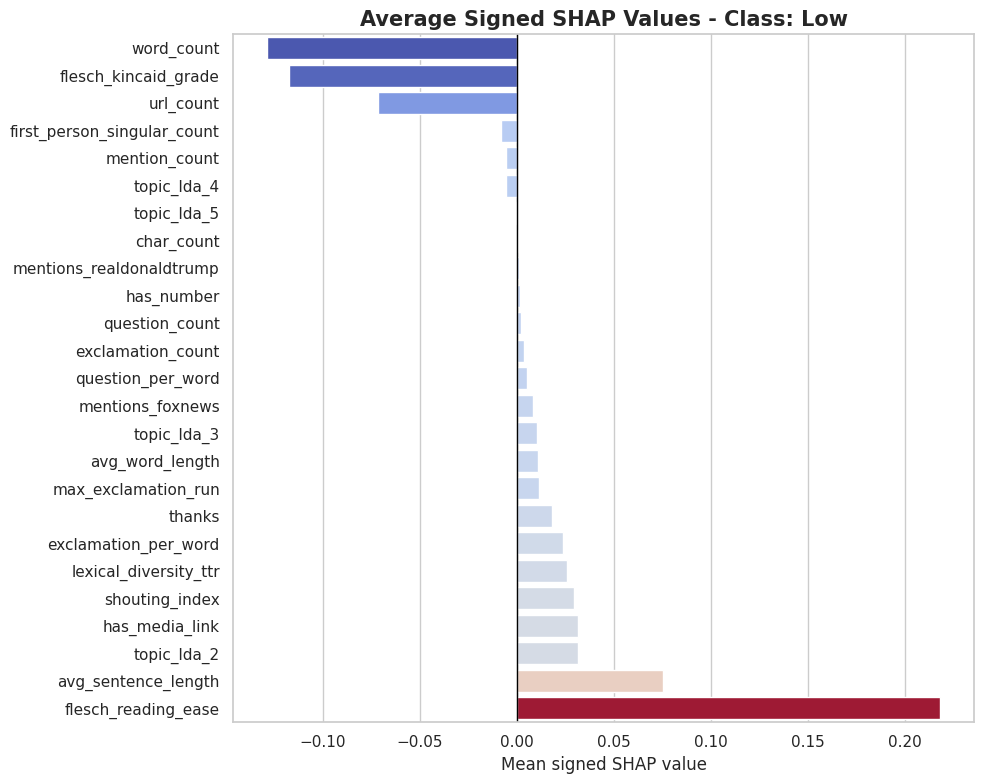

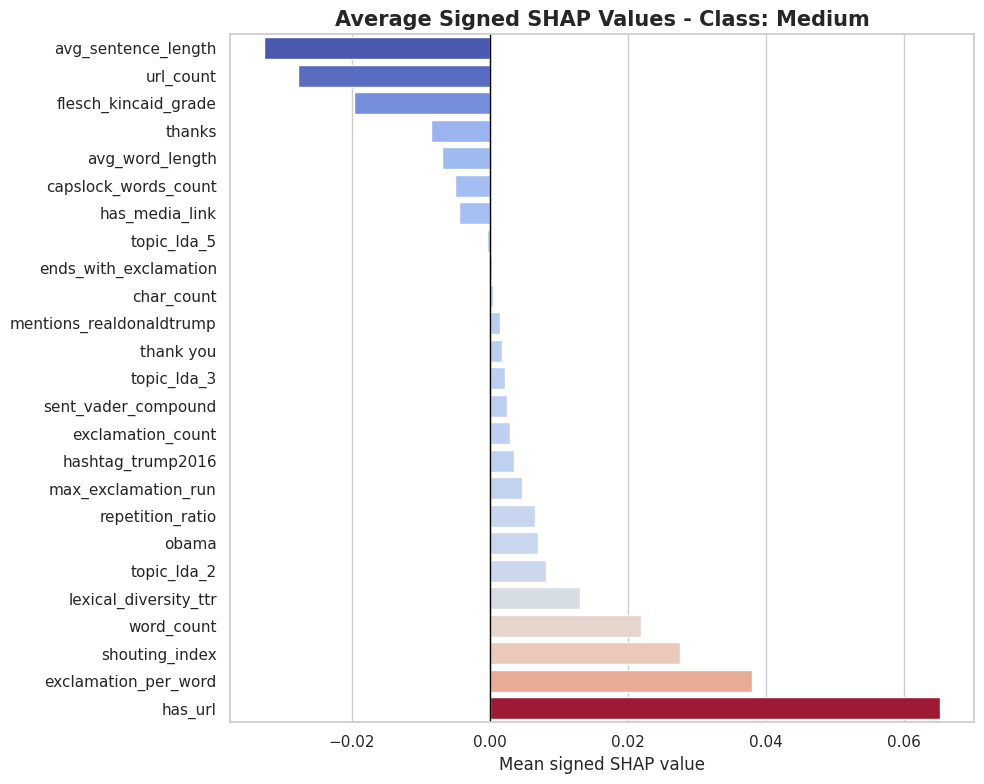

In [23]:
for class_idx, class_name in enumerate(label_classes):
    if class_idx >= shap_values.shape[-1]:
        continue

    class_df = class_importance_all[class_importance_all["class_id"] == class_idx].copy()
    top_features = class_df.head(TOP_N_FEATURES)["feature"].tolist()
    signed_df = class_df[class_df["feature"].isin(top_features)].copy().sort_values("mean_signed_shap")

    plt.figure(figsize=(10, 8))
    sns.barplot(data=signed_df, x="mean_signed_shap", y="feature", hue="mean_signed_shap", legend=False, palette="coolwarm")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Average Signed SHAP Values - Class: {class_name}", fontsize=15, fontweight="bold")
    plt.xlabel("Mean signed SHAP value")
    plt.ylabel("")
    plt.tight_layout()
    safe_name = str(class_name).replace(" ", "_").lower()
    plt.show()

### Text features vs engineered numeric features

,feature_type,mean_abs_shap,share
0,engineered_numeric,5.302297,0.656231
1,text_ngram,2.777630,0.343769


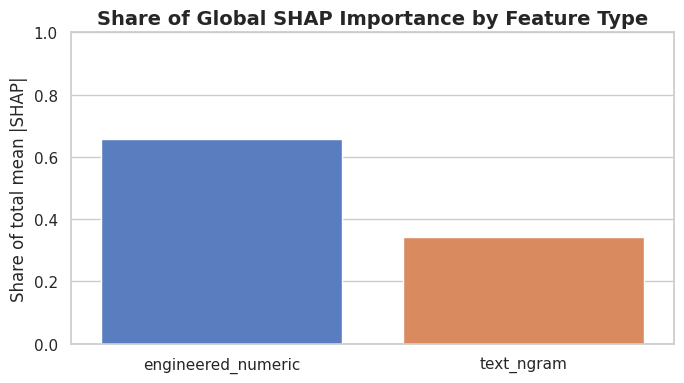

In [24]:
feature_type_summary = (
    global_importance
    .groupby("feature_type", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
)
feature_type_summary["share"] = feature_type_summary["mean_abs_shap"] / feature_type_summary["mean_abs_shap"].sum()

display(feature_type_summary)

plt.figure(figsize=(7, 4))
sns.barplot(data=feature_type_summary, x="feature_type", y="share", hue="feature_type", legend=False)
plt.title("Share of Global SHAP Importance by Feature Type", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Share of total mean |SHAP|")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### SHAP plots for selected classes

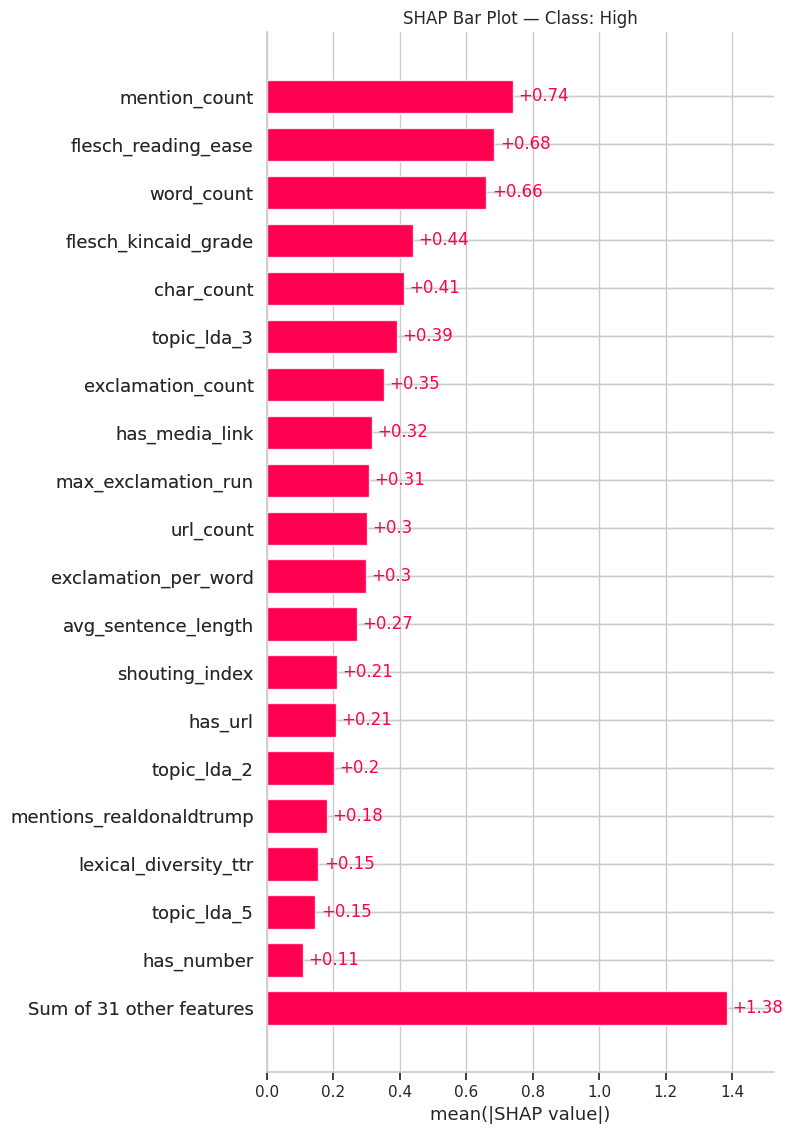

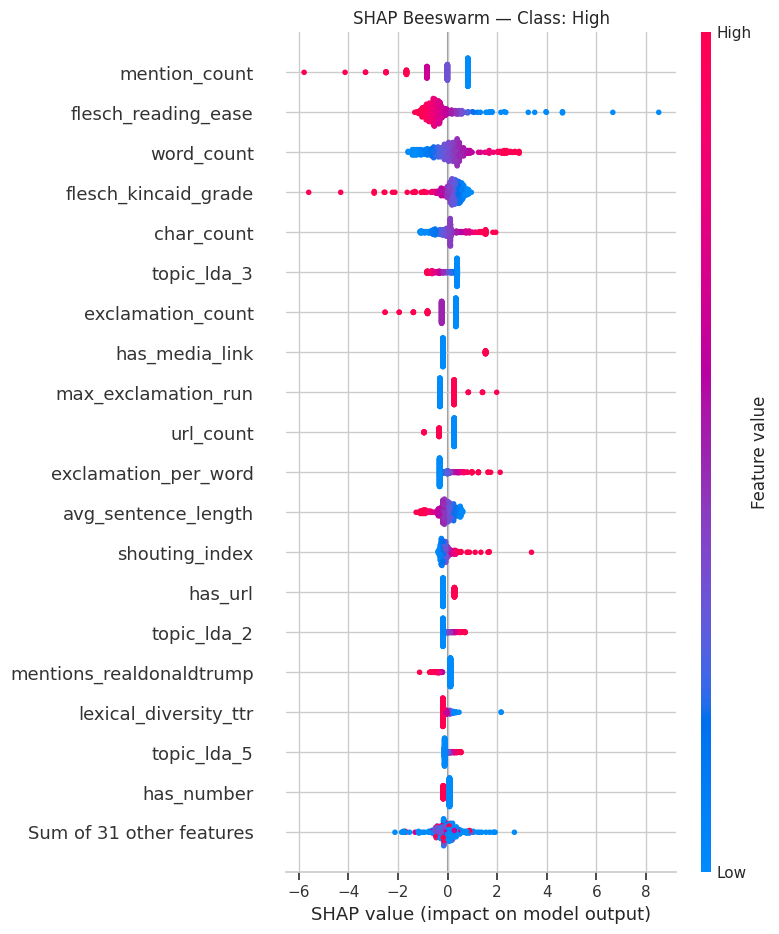

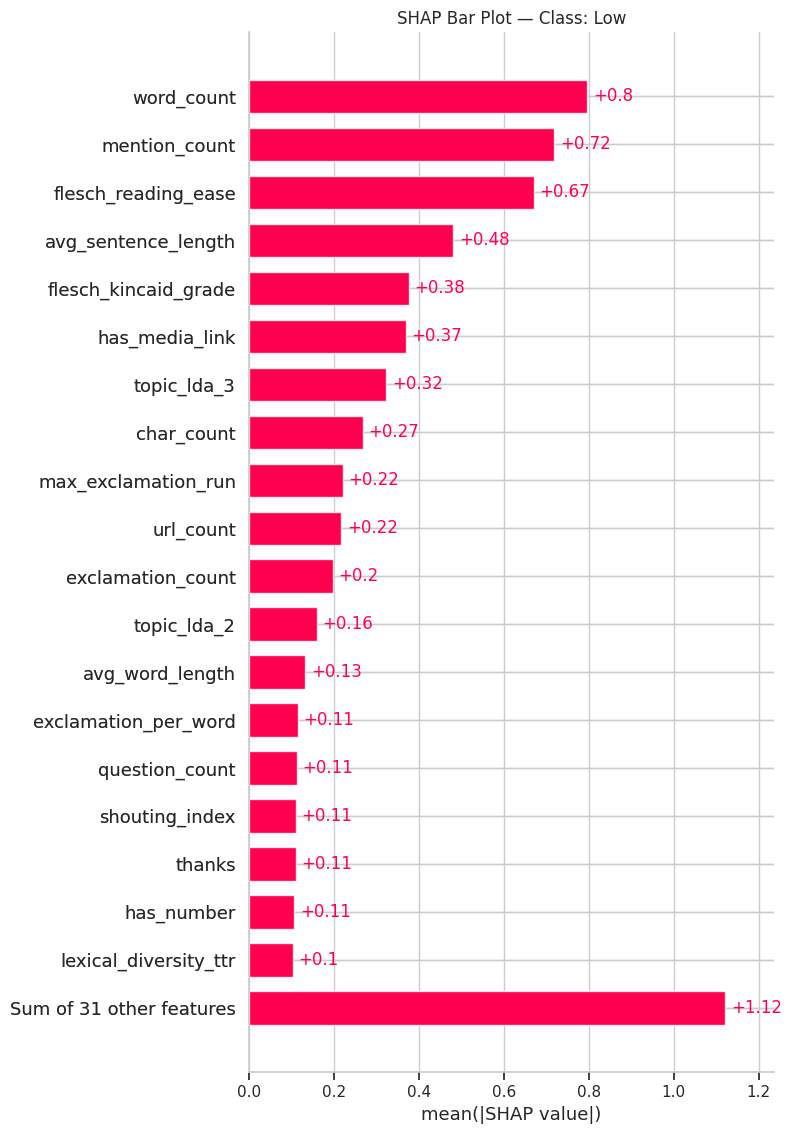

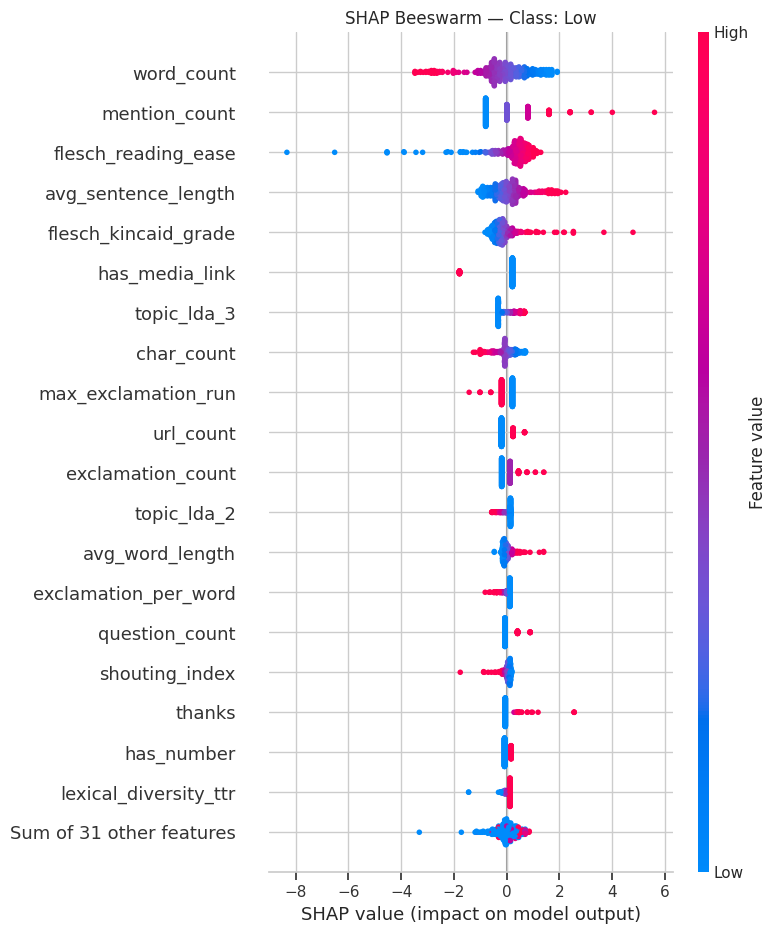

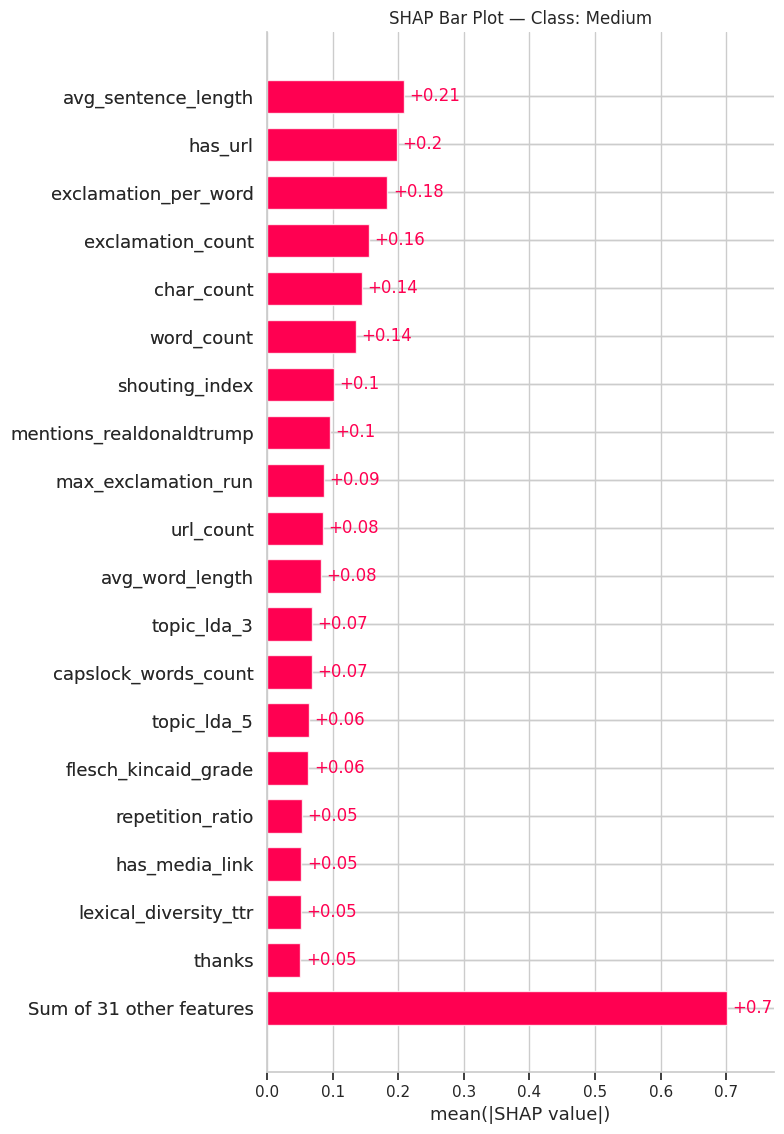

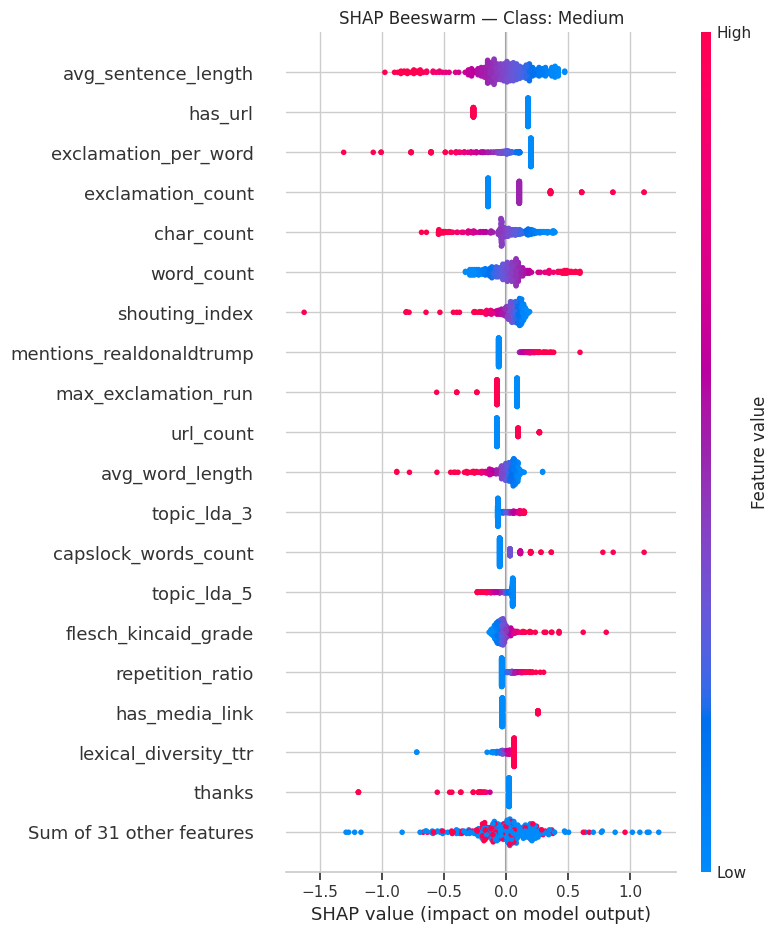

In [25]:
for class_idx, class_name in enumerate(label_classes):
    if class_idx >= shap_values.shape[-1]:
        continue

    # Restrict the Explanation to the top global features for speed/readability.
    top_feature_indices = global_importance.head(50).index.to_numpy()
    # global_importance index was reset and no longer equals original feature index; recover original indices:
    top_features = global_importance.head(50)["feature"].tolist()
    top_feature_indices = np.array([best_feature_names.index(f) for f in top_features])

    explanation = shap.Explanation(
        values=shap_values[:, top_feature_indices, class_idx],
        base_values=np.asarray(base_values)[:, class_idx] if np.asarray(base_values).ndim == 2 and class_idx < np.asarray(base_values).shape[1] else None,
        data=X_explain_dense[:, top_feature_indices],
        feature_names=[best_feature_names[i] for i in top_feature_indices],
    )

    plt.figure()
    shap.plots.bar(explanation, max_display=20, show=False)
    plt.title(f"SHAP Bar Plot — Class: {class_name}")
    plt.tight_layout()
    safe_name = str(class_name).replace(" ", "_").lower()
    plt.show()

    try:
        plt.figure()
        shap.plots.beeswarm(explanation, max_display=20, show=False)
        plt.title(f"SHAP Beeswarm — Class: {class_name}")
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print(f"Beeswarm failed for class {class_name}: {type(exc).__name__}: {exc}")

### Local explanation for selected tweets

Selected sample positions: [np.int64(12), np.int64(0), np.int64(1)]


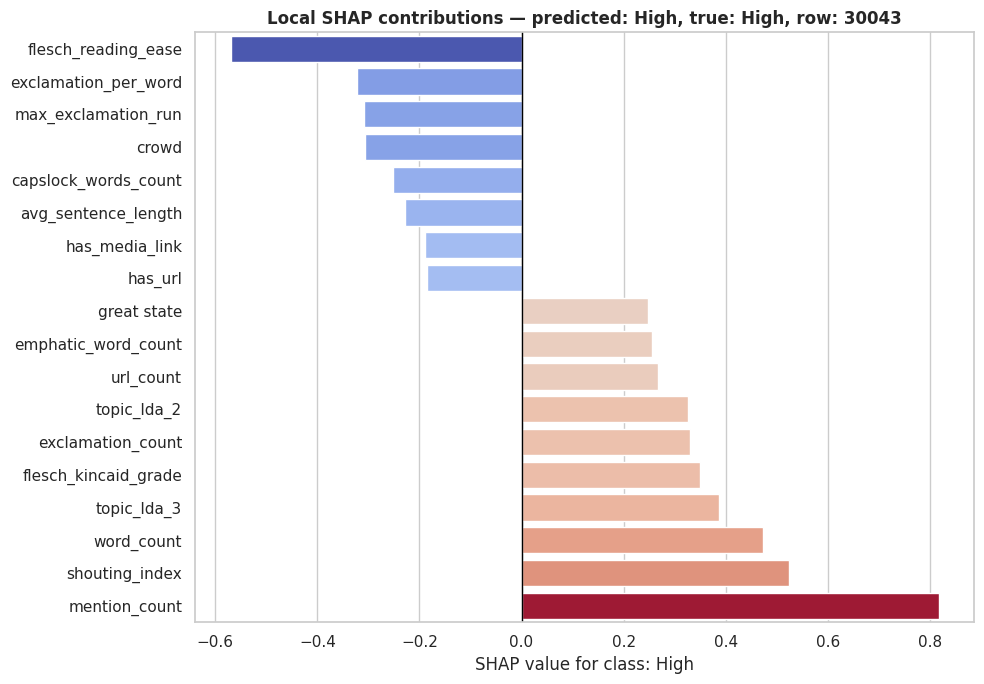

Tweet content:
I will be making a major speech on ILLEGAL IMMIGRATION on Wednesday in the GREAT State of Arizona. Big crowds, looking for a larger venue.
Retweets: 8772
Engagement level: High


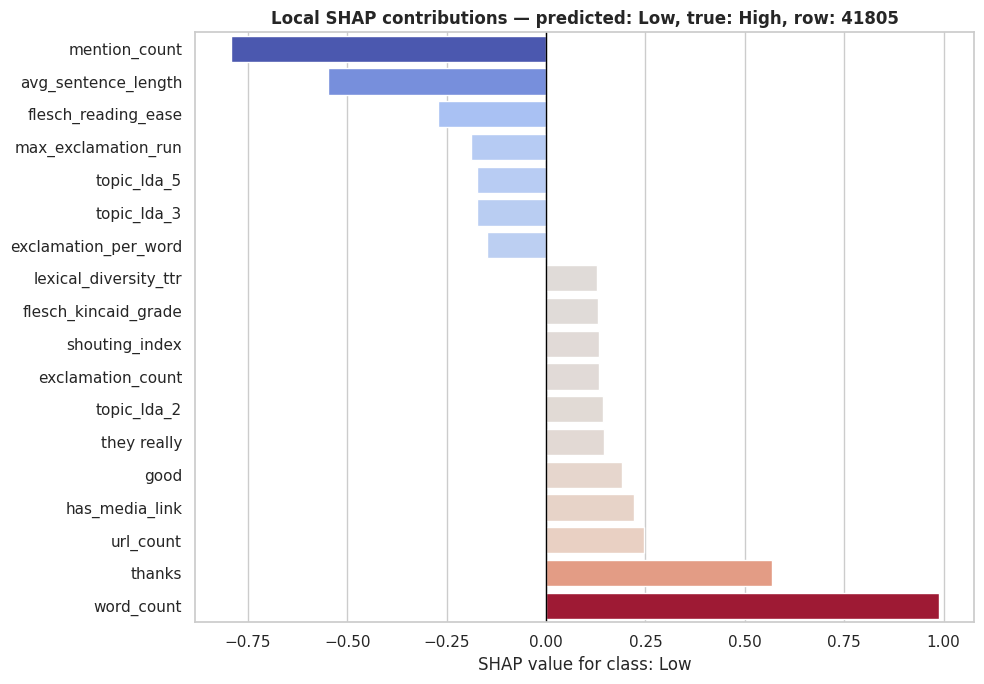

Tweet content:
Thanks Linda, but they were really good last night!https://twitter.com/LindaSuhler/status/1235720698527502338 …
Retweets: 10183
Engagement level: High


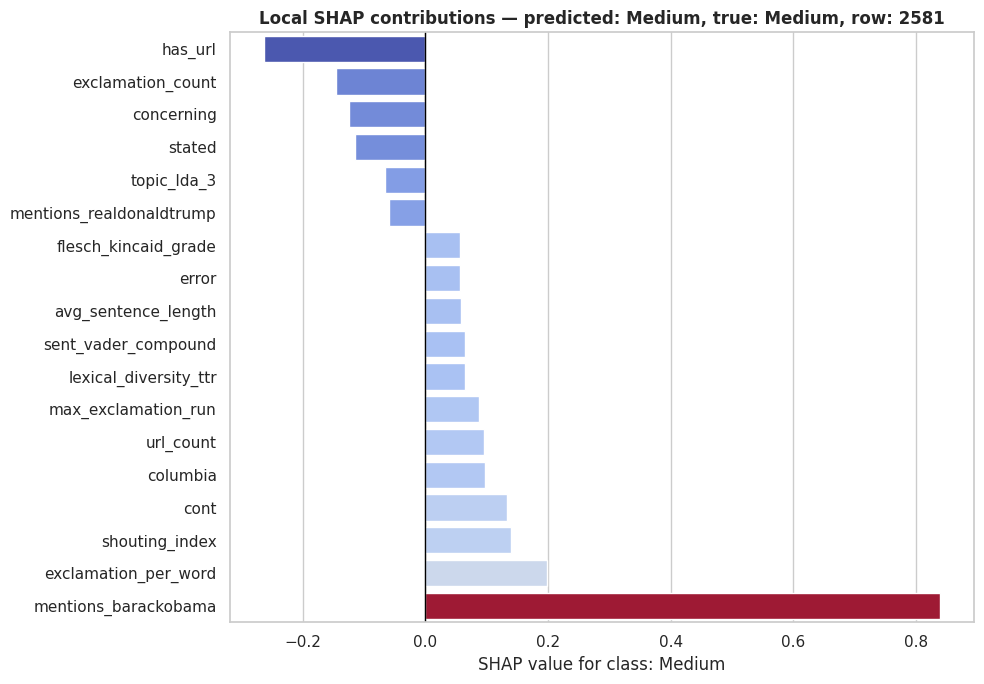

Tweet content:
Columbia University stated there was a "computer error" in their system concerning @ BarackObama's attendance. (cont) http://tl.gd/iddt8m
Retweets: 154
Engagement level: Medium


In [26]:
def plot_local_contribution(sample_pos, class_idx=None, top_n=20):
    """
    Plot top local feature contributions for one sample in X_explain.
    """
    if class_idx is None:
        class_idx = pred_explain[sample_pos]

    phi = shap_values[sample_pos, :, class_idx]
    top_idx = np.argsort(np.abs(phi))[-top_n:]

    local_df = pd.DataFrame({
        "feature": [best_feature_names[i] for i in top_idx],
        "shap_value": phi[top_idx],
    }).sort_values("shap_value")

    row_index = row_indices_explain[sample_pos]
    true_label = label_classes[y_explain[sample_pos]]
    pred_label = label_classes[pred_explain[sample_pos]]

    title = f"Local SHAP contributions — predicted: {pred_label}, true: {true_label}, row: {row_index}"

    plt.figure(figsize=(10, 7))
    sns.barplot(data=local_df, x="shap_value", y="feature", hue="shap_value", legend=False, palette="coolwarm")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel(f"SHAP value for class: {label_classes[class_idx]}")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    if df is not None and "content" in df.columns:
        print("Tweet content:")
        print(df.loc[row_index, "content"])
        print("Retweets:", df.loc[row_index, "retweets"] if "retweets" in df.columns else "N/A")
        print("Engagement level:", df.loc[row_index, "engagement_level"] if "engagement_level" in df.columns else "N/A")

    return local_df

# Select a few examples: one correct high-confidence-looking example per predicted class if possible.
examples = []
for class_idx in range(len(label_classes)):
    candidates = np.where(pred_explain == class_idx)[0]
    if len(candidates) > 0:
        examples.append(candidates[0])

print("Selected sample positions:", examples)

local_tables = []
for pos in examples[:min(3, len(examples))]:
    local_df = plot_local_contribution(pos, top_n=18)
    local_df["sample_position"] = pos
    local_df["row_index"] = row_indices_explain[pos]
    local_tables.append(local_df)

if local_tables:
    local_all = pd.concat(local_tables, ignore_index=True)